# Учебное соревнование Kaggle House Prices, Top5% result

В этом проекте я построил ансамблевую модель (AutoGluon + Optuna tuning),
которая достигла Top 5% на соревновании Kaggle House Prices.

Основной фокус:
- борьба с переобучением
- feature engineering
- настройка ансамбля моделей

## PIP

In [1]:
!pip install autogluon.tabular

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.1 MB/s eta 0:00:00


In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.8 MB/s eta 0:00:00


In [3]:
!pip install autogluon.tabular[fastai]==1.5.0

INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 638.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 M

In [4]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.8 MB/s eta 0:00:00


## Imports & Settings

In [111]:
import time
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from autogluon.tabular import TabularPredictor
from catboost import CatBoostRegressor
print("OK")

OK


In [5]:
RANDOM_STATE = 42
TARGET_NAME = 'SalePrice'
N_THREADS = 8
N_FOLDS = 5
TEST_SIZE = 0.2

np.random.seed(RANDOM_STATE)

## DataLoad

In [157]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [32]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## EDA

In [31]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [30]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

MSZoning
LotFrontage
Alley
Utilities
Exterior1st
Exterior2nd
MasVnrType
MasVnrArea
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinSF1
BsmtFinType2
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
BsmtFullBath
BsmtHalfBath
KitchenQual
Functional
FireplaceQu
GarageType
GarageYrBlt
GarageFinish
GarageCars
GarageArea
GarageQual
GarageCond

In [ ]:
df_train['Alley'].value_counts()

Alley
Grvl    50
Pave    41
Name: count, dtype: int64

<Axes: >

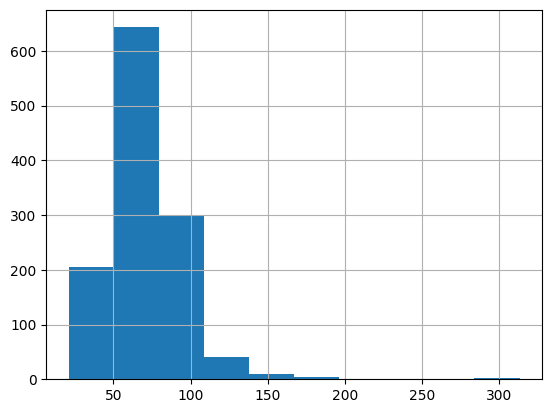

In [ ]:
df_train['LotFrontage'].hist()

<Axes: >

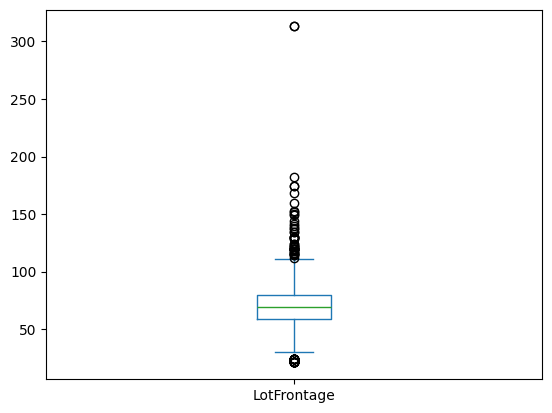

In [ ]:
df_train['LotFrontage'].plot.box()

In [ ]:
df_train[['LotFrontage', 'LotArea', 'SalePrice']].describe()

,LotFrontage,LotArea,SalePrice
count,1201.000000,1460.000000,1460.000000
mean,70.049958,10516.828082,180921.195890
std,24.284752,9981.264932,79442.502883
min,21.000000,1300.000000,34900.000000
25%,59.000000,7553.500000,129975.000000
50%,69.000000,9478.500000,163000.000000
75%,80.000000,11601.500000,214000.000000
max,313.000000,215245.000000,755000.000000


In [ ]:
df_train[df_train['LotFrontage'] > 200]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
934,935,20,RL,313.0,27650,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,11,2008,WD,Normal,242000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


In [ ]:
df_train['MasVnrType'].value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [ ]:
num_cols = df_train.select_dtypes(include='number').columns.tolist()
num_cols

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

In [ ]:
df_train[num_cols].describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
df_train['GrLivArea'].describe()

count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
max      5642.000000
Name: GrLivArea, dtype: float64

In [ ]:
desc = df_train[num_cols].describe()

for col in num_cols:
    max_val = desc[col]['max']
    q75 = desc[col]['75%']

    if q75 == 0:
        continue  # пропускаем колонки где 75% = 0

    if max_val > q75 * 3:
        print(f"{col}: max={max_val:.0f}, 75%={q75:.0f}, ratio={max_val/q75:.1f}x")

LotFrontage: max=313, 75%=80, ratio=3.9x
LotArea: max=215245, 75%=11602, ratio=18.6x
MasVnrArea: max=1600, 75%=166, ratio=9.6x
BsmtFinSF1: max=5644, 75%=712, ratio=7.9x
TotalBsmtSF: max=6110, 75%=1298, ratio=4.7x
1stFlrSF: max=4692, 75%=1391, ratio=3.4x
GrLivArea: max=5642, 75%=1777, ratio=3.2x
WoodDeckSF: max=857, 75%=168, ratio=5.1x
OpenPorchSF: max=547, 75%=68, ratio=8.0x
SalePrice: max=755000, 75%=214000, ratio=3.5x


## Data Preparation

Основная задача preprocessing — привести train и test к согласованному виду и корректно обработать пропуски без утечки данных.

Обработка пропусков

Пропуски в данных имеют разную природу, поэтому для разных групп признаков применялись разные стратегии:

- **Категориальные признаки, где NA означает отсутствие объекта**  
  (например, `GarageType`, `BsmtQual`, `FireplaceQu`)  
  → заполнялись значением `"NA"`

- **Числовые признаки, связанные с отсутствием объекта**  
  (например, `GarageArea`, `BsmtFinSF1`, `TotalBsmtSF`)  
  → заполнялись значением `0`

- **Признаки с “неизвестным значением”**  
  (например, `MSZoning`, `KitchenQual`, `SaleType`)  
  → заполнялись модой, рассчитанной **только на train**

- **LotFrontage**  
  → заполнялся медианой по `Neighborhood`, рассчитанной на train  
  → если значение всё ещё отсутствует — используется глобальная медиана

- **Специальные случаи**
  - `MasVnrType` → `"None"`
  - `GarageYrBlt` → `YearBuilt`

Избежание утечки данных

Все статистики (медианы, моды) рассчитывались **исключительно на train**,  
после чего применялись к test без пересчёта.

Это соответствует реальному production-сценарию:
> модель обучается на train и применяется к новым данным без доступа к их распределению.

Согласованность train/test

Изначально в тестовом наборе присутствовали пропуски в признаках,  
которые в train были полностью заполнены (например, `GarageArea`, `BsmtFullBath`).

Это приводило к предупреждениям AutoGluon и потенциальному ухудшению качества.

После явной обработки пропусков:
- train и test стали согласованными
- исключён скрытый distribution shift

Замечание

В идеале preprocessing должен быть максимально детализированным и учитывать
семантику каждой отдельной фичи.

Однако в рамках данной задачи использован сбалансированный подход:
- бизнес-логика применена к ключевым признакам
- для остальных использованы устойчивые статистические методы

Это позволяет избежать избыточного усложнения пайплайна при сохранении качества модели.

В дальнейшем возможное улучшение — построение полностью feature-specific preprocessing,
где каждая переменная обрабатывается с учётом её доменной интерпретации.

In [158]:
def fit_preprocessing_stats(df_train):
    stats = {}

    stats['lot_frontage_medians'] = (
        df_train.groupby('Neighborhood')['LotFrontage'].median().to_dict()
    )

    stats['cat_modes'] = {
        col: df_train[col].mode(dropna=True)[0]
        for col in ['MSZoning', 'Utilities', 'Exterior1st',
                    'Exterior2nd', 'KitchenQual', 'Functional', 'Electrical']
    }

    stats['num_zero_cols'] = [
        'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
        'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',
        'GarageCars', 'GarageArea'
    ]

    return stats

In [159]:
clip_cols = ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1',
             'TotalBsmtSF', '1stFlrSF', 'WoodDeckSF', 'OpenPorchSF']

In [160]:
def preprocessing(df, stats=None, is_train=True):
    df = df.copy()

    if is_train:
        df = df[~(df['GrLivArea'] > 4000)]

    df['LotFrontage'] = df['Neighborhood'].map(stats['lot_frontage_medians']).where(df['LotFrontage'].isna(), df['LotFrontage'])

    # если вдруг после map остались NaN
    global_lotfrontage_median = pd.Series(stats['lot_frontage_medians']).median()
    df['LotFrontage'] = df['LotFrontage'].fillna(global_lotfrontage_median)

    na_cols = [
        'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
        'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
        'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
        'PoolQC', 'Fence', 'MiscFeature'
    ]
    for col in na_cols:
        df[col] = df[col].fillna('NA')

    for col in stats['num_zero_cols']:
        df[col] = df[col].fillna(0)

    df['MasVnrType'] = df['MasVnrType'].fillna('None')
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

    for col, mode_val in stats['cat_modes'].items():
        df[col] = df[col].fillna(mode_val)
    df['SaleType'] = df['SaleType'].fillna('Oth')

    return df

In [161]:
def quantile_scorer(series):
    q25 = series.quantile(0.25)
    q75 = series.quantile(0.75)
    iqr = q75 - q25
    return (q25 - 1.5 * iqr, q75 + 1.5 * iqr)

In [162]:
def make_borders(df, cols):
    borders = {}
    for col in cols:
        low, high = quantile_scorer(df[col])
        borders[col] = (low, high)
    return borders

In [163]:
def apply_borders(df, borders):
    df = df.copy()
    for col, (low, high) in borders.items():
        df[col] = df[col].clip(lower=low, upper=high)
    return df

In [164]:
df_train_for_stats = df_train.copy()
df_train_for_stats = df_train_for_stats[~(df_train_for_stats['GrLivArea'] > 4000)]

stats = fit_preprocessing_stats(df_train_for_stats)

In [165]:
df_train_processed = preprocessing(df_train, stats, True)
df_test_processed = preprocessing(df_test, stats, False)

In [166]:
df_train_processed.isna().sum().sum()

np.int64(0)

In [167]:
df_test_processed.isna().sum().sum()

np.int64(0)

In [168]:
borders = make_borders(df_train_processed, clip_cols)

In [169]:
df_train_processed = apply_borders(df_train_processed, borders)
df_test_processed = apply_borders(df_test_processed, borders)

## Feature Engineering

Feature engineering направлен на усиление сигнала и упрощение структуры данных для модели.

 Основные идеи

При построении признаков использовались три ключевых принципа:
- агрегирование информации
- учёт доменной логики
- снижение шума в исходных признаках

 Ключевые признаки

- **OverallScore**  
  = OverallQual × OverallCond  
  → учитывает совместное влияние качества и состояния дома  
  → позволяет модели лучше различать объекты с одинаковым качеством, но разным состоянием

- **TotalHouseSquare**  
  → суммарная площадь всех жилых и вспомогательных помещений  
  → уменьшает фрагментацию информации (вместо нескольких связанных признаков — один агрегированный)

- **HouseAge / RemodAge**  
  → преобразование года постройки и ремонта в возраст  
  → модель лучше работает с “возрастом”, чем с абсолютными годами

- **Бинарные признаки (Has\*)**  
  (например: `HasGarage`, `HasPool`, `HasFireplace`)  
  → явно кодируют наличие объекта  
  → помогают модели отделить “нет объекта” от “есть, но маленький”

 Дополнительные соображения

- Часть исходных признаков содержит шум или слабо влияет на целевую переменную  
  → агрегированные признаки позволяют усилить полезный сигнал

- Бинарные признаки особенно важны для моделей, чувствительных к разреженности данных

- Некоторые признаки намеренно не усложнялись (например, без высокоуровневых взаимодействий),  
  чтобы избежать переобучения на небольшом датасете

 Итог

Добавленные признаки позволяют:
- уменьшить зависимость от сырых признаков
- упростить структуру данных для моделей
- повысить устойчивость ансамбля

In [170]:
def new_features(df):
  df = df.copy()
  df['OverallScore'] = df['OverallQual'] * df['OverallCond']

  df['HouseAge'] = df['YrSold'] - df['YearBuilt']
  df['RemoteAge'] = df['YrSold'] - df['YearRemodAdd']

  df['TotalHouseSquare'] = df['TotalBsmtSF'] + df['GrLivArea']

  df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                      df['3SsnPorch'] + df['ScreenPorch'] + df['WoodDeckSF'])

  df['TotalBath'] = (df['FullBath'] + df['BsmtFullBath'] +
                   0.5 * df['HalfBath'] + 0.5 * df['BsmtHalfBath'])

  df['TotalLivingArea'] = df['GrLivArea'] + df['TotalBsmtSF']

  df['QualityArea'] = df['OverallQual'] * df['GrLivArea']
  df['GarageAreaPerCar'] = df['GarageArea'] / (df['GarageCars'] + 1)

  quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'PoolQC']
  df['HasPool'] = (df['PoolArea'] > 0).astype(int)
  df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
  df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
  df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)
  df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)
  df['HasWoodDeck'] = (df['WoodDeckSF'] > 0).astype(int)
  df['HasPorch'] = ((df['OpenPorchSF'] + df['EnclosedPorch'] +
                   df['3SsnPorch'] + df['ScreenPorch']) > 0).astype(int)
  df['HasFence'] = (df['Fence'] != 'NA').astype(int)
  df['HasAlley'] = (df['Alley'] != 'NA').astype(int)
  def quality_to_num(series):
    mapping = {
        'Ex': 5,  # Excellent
        'Gd': 4,  # Good
        'TA': 3,  # Typical/Average
        'Fa': 2,  # Fair
        'Po': 1,  # Poor
        'NA': 0   # Not present
    }
    return series.map(mapping).fillna(0)

  df['TotalQualityScore'] = 0
  for col in quality_cols:
    df[f'{col}_num'] = quality_to_num(df[col])
    df['TotalQualityScore'] += df[f'{col}_num']
  df.drop(columns=['HasBasement', 'TotalLivingArea'], inplace=True, errors='ignore')
  return df

In [171]:
df_train_processed = new_features(df_train_processed)
df_test_processed = new_features(df_test_processed)

In [172]:
df_train_processed['SalePrice'] = np.log1p(df_train_processed['SalePrice'])

## Modeling

Для построения модели использовался ансамблевый подход на базе AutoGluon.

Подход

В качестве базовых моделей были выбраны:
- LightGBM
- XGBoost
- CatBoost
+ Neural Network (PyTorch) (без тюнинга)

Для каждой бустинговой модели был проведён предварительный тюнинг гиперпараметров с помощью Optuna.

После этого оптимизированные параметры использовались в AutoGluon для построения ансамбля.

 Ансамбль (AutoGluon)

AutoGluon использовался как high-level инструмент для:
- bagging (k-fold ансамбли)
- stacking (многоуровневые ансамбли)
- автоматического выбора лучшей комбинации моделей

Это позволило:
- объединить сильные стороны разных моделей
- снизить variance
- повысить устойчивость результата

 Выбор пресета и контроль переобучения

Изначально рассматривался пресет `best_quality`, однако в ходе экспериментов было выявлено:

- более сложный ансамбль давал лучший score на внутренней валидации
- но демонстрировал признаки переобучения на внешних данных

 В итоге был выбран пресет:

- **`high_quality`** — как компромисс между качеством и обобщающей способностью

Дополнительно:
- использовался `use_bag_holdout=True` для более честной оценки ансамбля
- избегалось избыточное увеличение `num_bag_folds` и `num_bag_sets`

 Работа с переобучением

Основные меры:

- упрощение ансамбля (отказ от чрезмерно сложных конфигураций)
- контроль preprocessing (исключение distribution shift между train и test)
- использование holdout внутри AutoGluon
- отказ от избыточного feature engineering

 Итог

Финальная модель представляет собой ансамбль моделей (stacking + bagging),
обученный на предварительно оптимизированных базовых алгоритмах.

Такой подход позволил:
- достичь высокого качества на Kaggle
- сохранить устойчивость модели
- избежать переобучения сложного ансамбля

В ходе экспериментов наблюдался разрыв между score на валидации и внешними данными,
что указывало на переобучение ансамбля.

Переход от best_quality к high_quality позволил уменьшить этот разрыв
и получить более стабильный результат.

In [ ]:
predictor = TabularPredictor(
    label='SalePrice',
    eval_metric='rmse'
).fit(
    df_train_processed,
    presets='best_quality',
    time_limit=1800   
)

Без тюнинга Лучший ансамбль состоит из LightGBM, XGBoost, CatBoost, буду тюнить эти модели с помощью Optuna

### Optuna LGBM

In [143]:
X = df_train_processed.drop(columns=['SalePrice', 'Id'])
y = df_train_processed['SalePrice']

Использую K-folds для EarlyStopping

In [144]:
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbose': -1,
        'objective': 'regression',
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X):
        X_train = X.iloc[train_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        # Находим категориальные колонки внутри fold
        cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

        if cat_cols:
            encoder = OrdinalEncoder(
                handle_unknown='use_encoded_value',
                unknown_value=-1,
                encoded_missing_value=-1,
                dtype=np.int64,
            )

            X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols].astype(str))
            X_val[cat_cols] = encoder.transform(X_val[cat_cols].astype(str))

        model = lgb.LGBMRegressor(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric='rmse',
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False)
            ],
        )

        pred = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, pred))
        scores.append(rmse)

    return float(np.mean(scores))

In [145]:
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=100, show_progress_bar=True)

print("Лучшие параметры:", study_lgbm.best_params)
print("Лучший RMSE:", study_lgbm.best_value)

[I 2026-04-15 14:03:53,236] A new study created in memory with name: no-name-438b3ab4-9c70-4a9a-a486-21784e05b1ba


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-15 14:03:55,292] Trial 0 finished with value: 0.12363745821189563 and parameters: {'n_estimators': 980, 'max_depth': 8, 'learning_rate': 0.01956899283194084, 'num_leaves': 63, 'subsample': 0.845399140806878, 'colsample_bytree': 0.8635397174032384, 'min_child_samples': 47, 'reg_alpha': 0.14853774195604214, 'reg_lambda': 1.1465540520839991e-06}. Best is trial 0 with value: 0.12363745821189563.
[I 2026-04-15 14:03:56,360] Trial 1 finished with value: 0.12816674942015197 and parameters: {'n_estimators': 843, 'max_depth': 3, 'learning_rate': 0.00673021183005472, 'num_leaves': 141, 'subsample': 0.625973985028709, 'colsample_bytree': 0.8322026625209524, 'min_child_samples': 39, 'reg_alpha': 7.350393502011179e-07, 'reg_lambda': 6.021768685079768e-08}. Best is trial 0 with value: 0.12363745821189563.
[I 2026-04-15 14:03:57,637] Trial 2 finished with value: 0.12376350612317429 and parameters: {'n_estimators': 1958, 'max_depth': 5, 'learning_rate': 0.029433174457585705, 'num_leaves': 7

### Optuna XGB

In [118]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'random_state': 42,
        'verbosity': 0,
        'tree_method': 'hist'
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X):
        X_train = X.iloc[train_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        # категории
        cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

        if cat_cols:
            encoder = OrdinalEncoder(
                handle_unknown='use_encoded_value',
                unknown_value=-1
            )

            X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols].astype(str))
            X_val[cat_cols] = encoder.transform(X_val[cat_cols].astype(str))

        model = xgb.XGBRegressor(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        pred = model.predict(X_val)
        scores.append(np.sqrt(mean_squared_error(y_val, pred)))

    return float(np.mean(scores))

In [119]:
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print("Лучшие параметры:", study_xgb.best_params)
print("Лучший RMSE:", study_xgb.best_value)

[I 2026-04-15 10:02:51,923] A new study created in memory with name: no-name-bc01e1e0-1cf6-42b8-943c-a2b7ed2bbf52


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-15 10:03:05,165] Trial 0 finished with value: 0.12184526348262496 and parameters: {'n_estimators': 1738, 'max_depth': 8, 'learning_rate': 0.01027338714670228, 'subsample': 0.7456153134406278, 'colsample_bytree': 0.9479749647888625, 'min_child_weight': 4, 'reg_alpha': 5.6353496052169915e-05, 'reg_lambda': 1.8688636806674046e-06, 'gamma': 1.4919867977903431e-05}. Best is trial 0 with value: 0.12184526348262496.
[I 2026-04-15 10:03:12,690] Trial 1 finished with value: 0.120128690049716 and parameters: {'n_estimators': 1709, 'max_depth': 5, 'learning_rate': 0.010805935049629617, 'subsample': 0.9738282544866317, 'colsample_bytree': 0.7602672228089273, 'min_child_weight': 9, 'reg_alpha': 7.119904391423267e-07, 'reg_lambda': 7.48689942882784e-05, 'gamma': 0.00026782265317437627}. Best is trial 1 with value: 0.120128690049716.
[I 2026-04-15 10:03:17,642] Trial 2 finished with value: 0.11748438754043682 and parameters: {'n_estimators': 1053, 'max_depth': 5, 'learning_rate': 0.0071938

### Optuna CatBoost

In [121]:
X_cat = df_train_processed.drop(columns=['SalePrice', 'Id'])
y_cat = df_train_processed['SalePrice']

# cat_indices для CatBoost
cat_cols_for_cb = X_cat.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Категориальных колонок: {len(cat_cols_for_cb)}")
print(cat_cols_for_cb)

Категориальных колонок: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [124]:
def objective_cb(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 2000),
        'depth': trial.suggest_int('depth', 4, 10),           
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('random_strength', 1e-8, 10.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_seed': 42,
        'verbose': False,
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X_cat):
        X_train, X_val = X_cat.iloc[train_idx], X_cat.iloc[val_idx]
        y_train, y_val = y_cat.iloc[train_idx], y_cat.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(X_train, y_train,
                  eval_set=(X_val, y_val),
                  early_stopping_rounds=50,
                  cat_features=cat_cols_for_cb,
                  verbose=False)

        pred = model.predict(X_val)
        scores.append(np.sqrt(mean_squared_error(y_val, pred)))

    return np.mean(scores)

In [126]:
study_cb = optuna.create_study(direction='minimize')
study_cb.optimize(objective_cb, n_trials=30, show_progress_bar=True)

print("Лучшие параметры:", study_cb.best_params)
print("Лучший RMSE:", study_cb.best_value)

[I 2026-04-15 10:24:41,586] A new study created in memory with name: no-name-acb0733a-3b45-4f15-a0d8-1a5e93ffdd0f


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-15 10:25:18,810] Trial 0 finished with value: 0.11773405110322228 and parameters: {'iterations': 894, 'depth': 4, 'learning_rate': 0.02316213012256303, 'l2_leaf_reg': 0.002149409548859686, 'bagging_temperature': 0.9584446908449141, 'random_strength': 5.509569008823845e-06, 'border_count': 86}. Best is trial 0 with value: 0.11773405110322228.
[I 2026-04-15 10:26:32,656] Trial 1 finished with value: 0.12272427891589703 and parameters: {'iterations': 1603, 'depth': 8, 'learning_rate': 0.04745043446095036, 'l2_leaf_reg': 5.942989864176841e-06, 'bagging_temperature': 0.9613247445618203, 'random_strength': 0.01967440866635388, 'border_count': 61}. Best is trial 0 with value: 0.11773405110322228.
[I 2026-04-15 10:27:13,607] Trial 2 finished with value: 0.11811933439213047 and parameters: {'iterations': 708, 'depth': 6, 'learning_rate': 0.07560352390211397, 'l2_leaf_reg': 0.046139095122122574, 'bagging_temperature': 0.2764316011478216, 'random_strength': 0.00011981925036693546, 'bor

In [146]:
best_lgbm_params = study_lgbm.best_params

best_xgb_params = study_xgb.best_params

best_cb_params = study_cb.best_params

### Тестирование разных вариаций ансамблей

#### Лучшие тюнинг параметры

In [155]:
best_lgbm_params = {'n_estimators': 1831, 'max_depth': 4, 'learning_rate': 0.007461508370179653, 'subsample': 0.6267137119068049, 'colsample_bytree': 0.730711700650938, 'min_child_weight': 4, 'reg_alpha': 3.5570577106037735e-06, 'reg_lambda': 0.00015799281202836946, 'gamma': 3.897728780433203e-05}

best_xgb_params = {'n_estimators': 1831, 'max_depth': 4, 'learning_rate': 0.007461508370179653, 'subsample': 0.6267137119068049, 'colsample_bytree': 0.730711700650938, 'min_child_weight': 4, 'reg_alpha': 3.5570577106037735e-06, 'reg_lambda': 0.00015799281202836946, 'gamma': 3.897728780433203e-05}

best_cb_params = {'iterations': 1410, 'depth': 5, 'learning_rate': 0.02706538580358, 'l2_leaf_reg': 0.11909692668916888, 'bagging_temperature': 0.8046979995152731, 'random_strength': 0.08651291549292918, 'border_count': 82}


#### V1.0

In [95]:
hyperparameters = {
    'GBM': [study_lgbm.best_params, {}],
    'XGB': [study_xgb.best_params, {}],
    'CAT': [study_cb.best_params, {}],
    'FASTAI': {},
    'NN_TORCH': {},
    'RF': {},
    'XT': {},
}

predictor_tuned = TabularPredictor(
    label='SalePrice',
    eval_metric='root_mean_squared_error'
).fit(
    df_train_processed,
    hyperparameters=hyperparameters,
    presets='best_quality',
    time_limit=1800,
    num_bag_folds=10,
    num_bag_sets=2,
    use_bag_holdout=True,
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260414_012025"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       10.57 GB / 12.67 GB (83.4%)
Disk Space Avail:   65.22 GB / 112.64 GB (57.9%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=10, num_bag_sets=2
Beginning AutoGluon training ... Time limit = 1800s
AutoGluon will save models to "/content/Autoglu

[1000]	valid_set's rmse: 0.128678
[1000]	valid_set's rmse: 0.149264
[1000]	valid_set's rmse: 0.14824
[2000]	valid_set's rmse: 0.14812


	-0.1087	 = Validation score   (-root_mean_squared_error)
	39.35s	 = Training   runtime
	0.69s	 = Validation runtime
Fitting model: RandomForest_BAG_L1 ... Training model for up to 1145.33s of the 1745.49s of remaining time.
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=2, gpus=0
	-0.113	 = Validation score   (-root_mean_squared_error)
	8.71s	 = Training   runtime
	0.15s	 = Validation runtime
Fitting model: CatBoost_BAG_L1 ... Training model for up to 1136.25s of the 1736.41s of remaining time.
	Fitting 20 child models (S1F1 - S2F10) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=1, gpus=0)
	-0.1048	 = Validation score   (-root_mean_squared_error)
	294.88s	 = Training   runtime
	0.12s	 = Validation runtime
Fitting model: CatBoost_2_BAG_L1 ... Training model for up to 840.74s of the 1440.91s of remaining time.
	Fitting 20 child models (S1F1 - S2F10) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=1, gpus=0)
	Ran out of tim

Очень хороший результат на трейн выборке но на тестовой выборке показывает плохой результат, сильное переобучение

#### V2.0

только 1 уровень, в остальном без ограничений

In [31]:
hyperparameters1 = {
    'GBM': [best_lgbm_params, {}],
    'XGB': [
        best_xgb_params,
        {}
    ],
    'CAT': [
        best_cb_params,
        {'iterations': 1000}
    ],
    'FASTAI': {},
    'NN_TORCH': {},
    'RF': {},
    'XT': {},
}


In [32]:
predictor_tuned1 = TabularPredictor(
    label='SalePrice',
    eval_metric='root_mean_squared_error'
).fit(
    df_train_processed,
    hyperparameters=hyperparameters1,
    presets='best_quality',
    time_limit=1200,
    dynamic_stacking=False,
    num_stack_levels=0,  # только L1, без стекинга
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260414_042105"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       11.25 GB / 12.67 GB (88.8%)
Disk Space Avail:   76.13 GB / 107.72 GB (70.7%)
Presets specified: ['best_quality']
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=8, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 1200s
AutoGluon will save models to "/content/AutogluonModels/ag-20260414_042105"
Train Data Rows:    1456
Train Data Columns: 107
Label Column:       SalePrice
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label 

Хуже на трейн выборке но также на тестовой, все еще переобучение

In [33]:
predictions1 = np.expm1(predictor_tuned1.predict(df_test_processed))

#### V3.0 базовые + затюненные модели

буду использовать только 3 модели затюненные и дефолтные

In [34]:
hyperparameters2 = {
    'GBM': [best_lgbm_params, {}],
    'XGB': [
        best_xgb_params,
        {}
    ],
    'CAT': [
        best_cb_params,
        {'iterations': 1000}
    ],
}

In [35]:
predictor_tuned2 = TabularPredictor(
    label='SalePrice',
    eval_metric='root_mean_squared_error'
).fit(
    df_train_processed,
    hyperparameters=hyperparameters2,
    presets='best_quality',
    time_limit=1200,
    dynamic_stacking=False,
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260414_043454"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       11.13 GB / 12.67 GB (87.9%)
Disk Space Avail:   75.99 GB / 107.72 GB (70.5%)
Presets specified: ['best_quality']
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 1200s
AutoGluon will save models to "/content/AutogluonModels/ag-20260414_043454"
Train Data Rows:    1456
Train Data Columns: 107
Label Column:       SalePrice
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label 

Значительно хуже на трейн выборке, но примерно также на тест выборке, уменьшилось переобучение но точность самого ансамбля упала

In [36]:
predictions2 = np.expm1(predictor_tuned2.predict(df_test_processed))

#### V4.0 = V1.0 но с изменением FE

In [ ]:
hyperparameters3 = {
    'GBM': [study_lgbm.best_params, {}],
    'XGB': [study_xgb.best_params, {}],
    'CAT': [study_cb.best_params, {}],
    'FASTAI': {},
    'NN_TORCH': {},
    'RF': {},
    'XT': {},
}

predictor_tuned3 = TabularPredictor(
    label='SalePrice',
    eval_metric='root_mean_squared_error'
).fit(
    df_train_processed,
    hyperparameters=hyperparameters,
    presets='best_quality',
    time_limit=1800,
    num_bag_folds=10,
    num_bag_sets=2,
    use_bag_holdout=True,
)

In [41]:
predictions3 = np.expm1(predictor_tuned3.predict(df_test_processed))

#### Усреднение результатов 3 ансамблей моделей

In [42]:
final_predictions = (predictions1 + predictions2 + predictions3) / 3

Результат получился хуже чем с 1 моделью

#### V5.0 Облегчение ансамбля

Убрал нестабильные модели + взял более облегченный пресет(high_quality) что бы побороть переобучение

In [65]:
hyperparameters5 = {
    'GBM': [best_lgbm_params, {}],
    'XGB': [
        best_xgb_params,
        {}
    ],
    'CAT': [
        best_cb_params,
        {'iterations': 1000}
    ],
    'NN_TORCH': {},
}

In [66]:
predictor_tuned3 = TabularPredictor(
    label='SalePrice',
    eval_metric='root_mean_squared_error'
).fit(
    train_data=df_train_processed,
    hyperparameters=hyperparameters5,
    presets='high_quality',
    time_limit=1200,
    use_bag_holdout=True,
    dynamic_stacking='auto',
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260415_033526"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          6
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       8.18 GB / 15.93 GB (51.3%)
Disk Space Avail:   38.00 GB / 111.11 GB (34.2%)
Presets specified: ['high_quality']
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 1200s
AutoGluon will save models to "C:\Users\Максим\kagle _skllboxproject\AutogluonModels\ag-20260415_033526"
Train Data Rows:    1456
Train Data Columns: 108
Label Column:       SalePrice
AutoGluon i

[1000]	valid_set's rmse: 0.126177
[2000]	valid_set's rmse: 0.126049


	-0.1066	 = Validation score   (-root_mean_squared_error)
	10.47s	 = Training   runtime
	0.15s	 = Validation runtime
Fitting model: CatBoost_BAG_L2 ... Training model for up to 678.57s of the 678.57s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
	-0.1051	 = Validation score   (-root_mean_squared_error)
	90.37s	 = Training   runtime
	0.12s	 = Validation runtime
Fitting model: CatBoost_2_BAG_L2 ... Training model for up to 587.88s of the 587.87s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
	-0.1035	 = Validation score   (-root_mean_squared_error)
	126.57s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: XGBoost_BAG_L2 ... Training model for up to 461.04s of the 461.03s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6

In [67]:
predictions5 = np.expm1(predictor_tuned3.predict(df_test_processed))

In [69]:
submission = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': predictions5
})

Переработан препроцессинг(обрабатываются пропуски в тесте, которые не обрабатывались до) но результат все еще хуже

#### V6.0 Новый препроцессинг + картблан для AutoGluon

In [73]:
predictor6 = TabularPredictor(
    label='SalePrice',
    eval_metric='rmse'
).fit(
    df_train_processed,
    presets='best_quality',
    time_limit=1800,
    use_bag_holdout=True,
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260415_035654"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          6
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       8.23 GB / 15.93 GB (51.7%)
Disk Space Avail:   37.92 GB / 111.11 GB (34.1%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 1800s
AutoGluon will save models to "C:\Users\Максим\kagle _skllboxproject\AutogluonModels\ag-20260415_035654"
Train Data Rows:    1456
Train Da

[1000]	valid_set's rmse: 0.129427
[1000]	valid_set's rmse: 0.15363
[2000]	valid_set's rmse: 0.153629
[3000]	valid_set's rmse: 0.153629
[4000]	valid_set's rmse: 0.153629
[5000]	valid_set's rmse: 0.153629
[1000]	valid_set's rmse: 0.154272


	-0.1165	 = Validation score   (-root_mean_squared_error)
	44.31s	 = Training   runtime
	0.51s	 = Validation runtime
Fitting model: CatBoost_r177_BAG_L1 ... Training model for up to 639.19s of the 1239.37s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
	-0.1037	 = Validation score   (-root_mean_squared_error)
	75.11s	 = Training   runtime
	0.07s	 = Validation runtime
Fitting model: NeuralNetTorch_r79_BAG_L1 ... Training model for up to 563.81s of the 1163.99s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
C:\Anaconda\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\compose\_colu

[1000]	valid_set's rmse: 0.136279
[1000]	valid_set's rmse: 0.11651


	-0.1085	 = Validation score   (-root_mean_squared_error)
	13.93s	 = Training   runtime
	0.23s	 = Validation runtime
Fitting model: NeuralNetFastAI_r191_BAG_L1 ... Training model for up to 473.74s of the 1073.92s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
No improvement since epoch 18: early stopping
	-0.1068	 = Validation score   (-root_mean_squared_error)
	27.46s	 = Training   runtime
	0.28s	 = Validation runtime
Fitting model: CatBoost_r9_BAG_L1 ... Training model for up to 445.61s of the 1045.79s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
	Ran out of time, early stopping on iteration 595.
	Ran out of time, early stopping on iteration 601.
	Ran out of time, early stopping on iteration 620.
	Ran out of time, early stopping on iteration 656.
	Ran out of time, early stopping on iteration 670.
	Ran out o

[1000]	valid_set's rmse: 0.113643
[1000]	valid_set's rmse: 0.130025
[2000]	valid_set's rmse: 0.129212
[1000]	valid_set's rmse: 0.0993269
[1000]	valid_set's rmse: 0.136237
[1000]	valid_set's rmse: 0.140618
[2000]	valid_set's rmse: 0.138788
[3000]	valid_set's rmse: 0.138098


	Ran out of time, early stopping on iteration 3802. Best iteration is:
	[3173]	valid_set's rmse: 0.137934


[1000]	valid_set's rmse: 0.112489
[1000]	valid_set's rmse: 0.115016
[1000]	valid_set's rmse: 0.129061


	-0.1087	 = Validation score   (-root_mean_squared_error)
	11.57s	 = Training   runtime
	0.26s	 = Validation runtime
Fitting model: NeuralNetTorch_r22_BAG_L1 ... Training model for up to 5.18s of the 605.36s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
C:\Anaconda\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(
	Ran out of time, stopping training early. (Stopping on epoch 2)
C:\Anaconda\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(
	Ran out of time, stopping training early. (Stopping on epoch 2)
C:\Ana

In [75]:
predictions6 = np.expm1(predictor6.predict(df_test_processed, model='WeightedEnsemble_L3'))

In [76]:
submission = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': predictions6
})

Без улучшения результата

#### V7.0 Одиночный CatBoost в качестве эксперимента

In [86]:
X_cat = df_train_processed.drop(columns=['SalePrice', 'Id'])
y_cat = df_train_processed['SalePrice']

In [87]:
cat_cols_for_cb = X_cat.select_dtypes(include=['object', 'category']).columns.tolist()

In [89]:
X_test_cat = df_test_processed.drop(columns=['Id'], errors='ignore')
X_test_cat = X_test_cat[X_cat.columns]

In [90]:
print(list(X_cat.columns) == list(X_test_cat.columns))
print(X_cat.select_dtypes(include=['object', 'category']).columns.tolist())

True
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [98]:
model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    random_state=42,
    verbose=0
)

model.fit(X_cat, y_cat,
                  cat_features=cat_cols_for_cb,
                  verbose=False)

preds = model.predict(X_test_cat)

In [100]:
submission = pd.DataFrame({
    'Id': df_test_processed['Id'],
    'SalePrice': np.expm1(preds)
})

#### V8.0 Ансамбль из 3 моделей не тюненных

In [99]:
hyperparameters8 = {
    'GBM': {},
    'XGB': {},
    'CAT': {},
}

In [106]:
predictor8 = TabularPredictor(
    label='SalePrice',
    eval_metric='root_mean_squared_error'
).fit(
    train_data=df_train_processed.drop(columns='Id'),
    hyperparameters=hyperparameters8,
    presets='high_quality',
    time_limit=1200,
    use_bag_holdout=True,
    dynamic_stacking='auto',
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260415_044709"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          6
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       7.83 GB / 15.93 GB (49.1%)
Disk Space Avail:   37.48 GB / 111.11 GB (33.7%)
Presets specified: ['high_quality']
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 1200s
AutoGluon will save models to "C:\Users\Максим\kagle _skllboxproject\AutogluonModels\ag-20260415_044709"
Train Data Rows:    1456
Train Data Columns: 107
Label Column:       SalePrice
AutoGluon i

[1000]	valid_set's rmse: 0.134934


	-0.1054	 = Validation score   (-root_mean_squared_error)
	7.23s	 = Training   runtime
	0.1s	 = Validation runtime
Fitting model: CatBoost_BAG_L2 ... Training model for up to 878.49s of the 878.48s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
	-0.1044	 = Validation score   (-root_mean_squared_error)
	165.43s	 = Training   runtime
	0.07s	 = Validation runtime
Fitting model: XGBoost_BAG_L2 ... Training model for up to 712.79s of the 712.78s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
	-0.1079	 = Validation score   (-root_mean_squared_error)
	9.95s	 = Training   runtime
	0.2s	 = Validation runtime
Fitting model: WeightedEnsemble_L3 ... Training model for up to 360.00s of the 702.42s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=6, gpus=0, mem=0.0/7.8 GB
	Ensemble Weights: {'CatBoost_BAG_

In [107]:
predictions8 = np.expm1(predictor8.predict(df_test_processed.drop(columns='Id')))

In [108]:
submission = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': predictions8
})

#### V9.0 Ансамбль из 3 моделей затюненных

In [128]:
hyperparameters9 = {
    'GBM': best_lgbm_params,
    'XGB': best_xgb_params,
    'CAT': best_cb_params,
}

In [129]:
predictor9 = TabularPredictor(
    label='SalePrice',
    eval_metric='root_mean_squared_error'
).fit(
    train_data=df_train_processed.drop(columns='Id'),
    hyperparameters=hyperparameters9,
    presets='best_quality',
    time_limit=1800,
    use_bag_holdout=True,
    dynamic_stacking='auto',
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260415_060634"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          6
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       8.39 GB / 15.93 GB (52.7%)
Disk Space Avail:   37.44 GB / 111.11 GB (33.7%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 1800s
AutoGluon will save models to "C:\Users\Максим\kagle _skllboxproject\AutogluonModels\ag-20260415_060634"
Train Data Rows:    1456
Train Data Columns: 107
Label Column:       SalePrice
AutoGluon i

In [130]:
predictions9 = np.expm1(predictor9.predict(df_test_processed.drop(columns='Id')))

In [131]:
submission = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': predictions9
})

#### V10.0 новый препроцессинг

In [173]:
hyperparameters10 = {
    'GBM': [best_lgbm_params, {}],
    'XGB': [best_xgb_params, {}],
    'CAT': [
        best_cb_params,          # затюненный
        {'iterations': 1000}           # дефолтный но с ограничением
    ],
    'FASTAI': {},
    'NN_TORCH': {},
    'RF': {},
    'XT': {},
}

In [175]:
predictor_tuned10 = TabularPredictor(
    label='SalePrice',
    eval_metric='root_mean_squared_error'
).fit(
    df_train_processed.drop(columns='Id'),
    hyperparameters=hyperparameters10,
    presets='best_quality',
    time_limit=1800,
    use_bag_holdout=True,
    dynamic_stacking=False,
    num_stack_levels=1,
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260415_094022"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          6
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       7.67 GB / 15.93 GB (48.2%)
Disk Space Avail:   36.87 GB / 111.11 GB (33.2%)
Presets specified: ['best_quality']
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 1800s
AutoGluon will save models to "C:\Users\Максим\kagle _skllboxproject\AutogluonModels\ag-20260415_094022"
Train Data Rows:    1456
Train Data Columns: 106
Label Column:       SalePrice
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label

[1000]	valid_set's rmse: 0.113024
[1000]	valid_set's rmse: 0.128181
[1000]	valid_set's rmse: 0.111825
[1000]	valid_set's rmse: 0.13794
[1000]	valid_set's rmse: 0.151961
[1000]	valid_set's rmse: 0.0991613
[1000]	valid_set's rmse: 0.118686
[1000]	valid_set's rmse: 0.134365


	-0.1068	 = Validation score   (-root_mean_squared_error)
	10.5s	 = Training   runtime
	0.21s	 = Validation runtime
Fitting model: LightGBM_2_BAG_L1 ... Training model for up to 1188.21s of the 1788.40s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)


[1000]	valid_set's rmse: 0.13175


	-0.1085	 = Validation score   (-root_mean_squared_error)
	8.08s	 = Training   runtime
	0.12s	 = Validation runtime
Fitting model: RandomForest_BAG_L1 ... Training model for up to 1179.78s of the 1779.97s of remaining time.
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=6, gpus=0
	-0.1126	 = Validation score   (-root_mean_squared_error)
	1.77s	 = Training   runtime
	0.1s	 = Validation runtime
Fitting model: CatBoost_BAG_L1 ... Training model for up to 1177.71s of the 1777.90s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
	-0.1037	 = Validation score   (-root_mean_squared_error)
	219.13s	 = Training   runtime
	0.09s	 = Validation runtime
Fitting model: CatBoost_2_BAG_L1 ... Training model for up to 958.26s of the 1558.45s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
	-0.1028	 = Validati

[1000]	valid_set's rmse: 0.129704
[1000]	valid_set's rmse: 0.102649
[1000]	valid_set's rmse: 0.111476


	-0.1035	 = Validation score   (-root_mean_squared_error)
	6.58s	 = Training   runtime
	0.14s	 = Validation runtime
Fitting model: LightGBM_2_BAG_L2 ... Training model for up to 1196.32s of the 1196.30s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
	-0.104	 = Validation score   (-root_mean_squared_error)
	7.88s	 = Training   runtime
	0.12s	 = Validation runtime
Fitting model: RandomForest_BAG_L2 ... Training model for up to 1188.13s of the 1188.11s of remaining time.
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=6, gpus=0
	-0.1058	 = Validation score   (-root_mean_squared_error)
	2.22s	 = Training   runtime
	0.09s	 = Validation runtime
Fitting model: CatBoost_BAG_L2 ... Training model for up to 1185.60s of the 1185.59s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
	-0.1027	 = Validatio

In [176]:
predictions10 = np.expm1(predictor_tuned10.predict(df_test_processed.drop(columns='Id')))

In [192]:
submission = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': predictions10
})

На данный момент лучший результат

#### V11 Для блендинга сабмитов _b

In [177]:
hyperparameters_b = {
    'GBM': [best_lgbm_params, {}],
    'XGB': [best_xgb_params],
    'CAT': [best_cb_params, {'iterations': 1000}],
}

In [178]:
predictor_b = TabularPredictor(
    label='SalePrice',
    eval_metric='root_mean_squared_error'
).fit(
    df_train_processed.drop(columns='Id'),
    hyperparameters=hyperparameters_b,
    presets='high_quality',
    time_limit=1800,
    use_bag_holdout=True,
    num_stack_levels=0,
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260415_095658"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          6
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       7.91 GB / 15.93 GB (49.6%)
Disk Space Avail:   36.62 GB / 111.11 GB (33.0%)
Presets specified: ['high_quality']
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=8, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 1800s
AutoGluon will save models to "C:\Users\Максим\kagle _skllboxproject\AutogluonModels\ag-20260415_095658"
Train Data Rows:    1456
Train Data Columns: 106
Label Column:       SalePrice
AutoGluon i

[1000]	valid_set's rmse: 0.113024
[1000]	valid_set's rmse: 0.128181
[1000]	valid_set's rmse: 0.111825
[1000]	valid_set's rmse: 0.13794
[1000]	valid_set's rmse: 0.151961
[1000]	valid_set's rmse: 0.0991613
[1000]	valid_set's rmse: 0.118686
[1000]	valid_set's rmse: 0.134365


	-0.1068	 = Validation score   (-root_mean_squared_error)
	10.13s	 = Training   runtime
	0.23s	 = Validation runtime
Fitting model: LightGBM_2_BAG_L1 ... Training model for up to 1788.70s of the 1788.70s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)


[1000]	valid_set's rmse: 0.13175


	-0.1085	 = Validation score   (-root_mean_squared_error)
	8.0s	 = Training   runtime
	0.13s	 = Validation runtime
Fitting model: CatBoost_BAG_L1 ... Training model for up to 1780.34s of the 1780.34s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
	-0.1037	 = Validation score   (-root_mean_squared_error)
	222.53s	 = Training   runtime
	0.09s	 = Validation runtime
Fitting model: CatBoost_2_BAG_L1 ... Training model for up to 1557.50s of the 1557.50s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
	-0.1028	 = Validation score   (-root_mean_squared_error)
	224.26s	 = Training   runtime
	0.08s	 = Validation runtime
Fitting model: XGBoost_BAG_L1 ... Training model for up to 1332.92s of the 1332.92s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: c

In [179]:
predictions_b = np.expm1(predictor_b.predict(df_test_processed.drop(columns='Id')))

#### V12 Для блендинга сабмитов _c

In [180]:
hyperparameters_c = {
    'XGB': [best_xgb_params, {}],
    'FASTAI': {},
    'NN_TORCH': {},
    'GBM': [best_lgbm_params, {}],
}

In [181]:
predictor_c = TabularPredictor(
    label='SalePrice',
    eval_metric='root_mean_squared_error'
).fit(
    df_train_processed.drop(columns='Id'),
    hyperparameters=hyperparameters_c,
    presets='high_quality',
    time_limit=1800,
    use_bag_holdout=True,
    num_stack_levels=1,
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260415_100625"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          6
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       7.92 GB / 15.93 GB (49.7%)
Disk Space Avail:   36.60 GB / 111.11 GB (32.9%)
Presets specified: ['high_quality']
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 1800s
AutoGluon will save models to "C:\Users\Максим\kagle _skllboxproject\AutogluonModels\ag-20260415_100625"
Train Data Rows:    1456
Train Data Columns: 106
Label Column:       SalePrice
AutoGluon i

[1000]	valid_set's rmse: 0.113024
[1000]	valid_set's rmse: 0.128181
[1000]	valid_set's rmse: 0.111825
[1000]	valid_set's rmse: 0.13794
[1000]	valid_set's rmse: 0.151961
[1000]	valid_set's rmse: 0.0991613
[1000]	valid_set's rmse: 0.118686
[1000]	valid_set's rmse: 0.134365


	-0.1068	 = Validation score   (-root_mean_squared_error)
	10.52s	 = Training   runtime
	0.22s	 = Validation runtime
Fitting model: LightGBM_2_BAG_L1 ... Training model for up to 1188.21s of the 1788.40s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)


[1000]	valid_set's rmse: 0.13175


	-0.1085	 = Validation score   (-root_mean_squared_error)
	8.31s	 = Training   runtime
	0.12s	 = Validation runtime
Fitting model: NeuralNetFastAI_BAG_L1 ... Training model for up to 1179.54s of the 1779.73s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
No improvement since epoch 9: early stopping
	-0.1059	 = Validation score   (-root_mean_squared_error)
	14.89s	 = Training   runtime
	0.26s	 = Validation runtime
Fitting model: XGBoost_BAG_L1 ... Training model for up to 1164.02s of the 1764.21s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
	-0.1043	 = Validation score   (-root_mean_squared_error)
	25.58s	 = Training   runtime
	0.37s	 = Validation runtime
Fitting model: XGBoost_2_BAG_L1 ... Training model for up to 1137.64s of the 1737.84s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with

[1000]	valid_set's rmse: 0.132853
[1000]	valid_set's rmse: 0.125736
[1000]	valid_set's rmse: 0.109939


	-0.1034	 = Validation score   (-root_mean_squared_error)
	7.61s	 = Training   runtime
	0.16s	 = Validation runtime
Fitting model: LightGBM_2_BAG_L2 ... Training model for up to 1641.19s of the 1641.18s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
	-0.1033	 = Validation score   (-root_mean_squared_error)
	8.91s	 = Training   runtime
	0.11s	 = Validation runtime
Fitting model: NeuralNetFastAI_BAG_L2 ... Training model for up to 1631.89s of the 1631.88s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=6, gpus=0)
No improvement since epoch 9: early stopping
	-0.1029	 = Validation score   (-root_mean_squared_error)
	15.07s	 = Training   runtime
	0.25s	 = Validation runtime
Fitting model: XGBoost_BAG_L2 ... Training model for up to 1616.19s of the 1616.18s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with

In [182]:
predictions_c = np.expm1(predictor_c.predict(df_test_processed.drop(columns='Id')))

#### Blending

In [183]:
final_prediction = 0.45 * predictions10 + 0.15 * predictions_b + 0.4 * predictions_c

Результат хуже одиночной модели V10.0

In [188]:
final_prediction = 0.8 * predictions10 + 0 * predictions_b + 0.2 * predictions_c

Хуже 0,45 + 0,15 + 0,4

### Сохранение submission

In [189]:
submission = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': final_prediction
})

In [190]:
submission.isna().sum()

Id           0
SalePrice    0
dtype: int64

In [193]:
submission.to_csv('submission.csv', index=False)

## Conclusion

В ходе экспериментов было протестировано несколько подходов к моделированию: базовый AutoGluon, ансамбли с дефолтными настройками, а также ансамбли с предварительно затюненными моделями (LightGBM, XGBoost, CatBoost).

Основные наблюдения
AutoGluon без тюнинга показал сильный baseline за счёт автоматического ансамблирования и bagging.

Optuna-тюнинг отдельных моделей улучшал их индивидуальное качество, но не всегда приводил к улучшению финального ансамбля.

Использование presets='best_quality' давало лучший CV score, но в ряде случаев ухудшало результат на Kaggle, что указывает на переобучение.

presets='high_quality' показал себя более устойчивым к переобучению и давал более стабильные результаты на публичном лидерборде.

Поведение ансамбля

Лучший результат достигался не за счёт одной модели, а за счёт ансамбля разнородных моделей.

В итоговом ансамбле наибольший вклад часто вносили:

- XGBoost
- нейросетевые модели (FastAI, NN_TORCH)
- При этом CatBoost, несмотря на хорошие индивидуальные метрики, получал меньший вес, что говорит о высокой корреляции ошибок с другими моделями.
- Stacking и сложность модели
- Увеличение глубины stacking (num_stack_levels > 1) не давало значимого прироста качества.
- На небольшом датасете (~1400 строк) более глубокий stacking приводил к:
- росту сложности модели
- отсутствию улучшения на валидации

Это указывает на достижение предела по сложности модели для данного объёма данных.

Блендинг моделей

Были протестированы различные варианты blending нескольких моделей:

ансамбли из нескольких AutoGluon моделей
разные веса (0.45 / 0.4 / 0.15 и др.)

Результат:

blending не улучшил лучший одиночный ансамбль
в большинстве случаев приводил к ухудшению качества

Причина: модели имели сильно коррелированные ошибки, и не давали достаточного разнообразия для эффективного блендинга.

Feature Engineering и preprocessing

Наибольший вклад в качество дали:
- агрегированные признаки (площади, ванные комнаты)
- бинарные признаки наличия объектов
- обработка пропусков с использованием бизнес-логики
- Clipping выбросов и удаление экстремальных значений (GrLivArea) улучшили устойчивость модели

Итог

Лучший результат на Kaggle: 0.1198x

Ключевой вывод:

Максимальное качество достигается не за счёт усложнения модели, а за счёт баланса между:
- качественным preprocessing
- осмысленным feature engineering
- и умеренно сложным ансамблем
- 
Практический вывод

- Сложные ансамбли (best_quality + stacking) не всегда лучше более простых и устойчивых конфигураций
- Блендинг эффективен только при наличии действительно различающихся моделей
- На небольших табличных датасетах: Feature Engineering > Hyperparameter Tuning > Model Complexity

Future Work
- Попробовать blending с принципиально отличающимися моделями (например, одиночный CatBoost vs AutoGluon)
- Добавить более сложные агрегаты качества (quality scores)
- Использовать более строгую кросс-валидацию вне AutoGluon